# Week 6: Statistical Validation and Predictive Maintenance

This notebook combines three tasks:
1. Statistical validation of an operational performance hypothesis.
2. Feature engineering from sensor data for predictive maintenance.
3. A simple predictive model to support maintenance decisions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')


Libraries imported successfully.


## 1. Load and Inspect the Operational Dataset

We will use a small operational dataset with machine performance times. The goal is to compare two machines and test whether one is faster than the other.


In [3]:
ops_df = pd.DataFrame({
    'machine': ['Machine A'] * 30 + ['Machine B'] * 30,
    'completion_time_min': [
        8.9, 9.1, 8.7, 9.2, 8.8, 9.0, 8.6, 9.3, 8.5, 8.9,
        9.4, 9.0, 8.8, 9.1, 8.7, 8.6, 9.2, 8.9, 9.3, 9.0,
        8.7, 8.8, 9.1, 8.5, 8.9, 9.2, 8.6, 8.8, 9.0, 8.7,
        10.1, 10.4, 10.8, 10.2, 10.6, 9.9, 10.3, 10.5, 10.7, 10.0,
        9.8, 10.2, 10.6, 10.1, 10.4, 10.7, 10.0, 9.7, 10.3, 10.5,
        9.9, 10.1, 10.4, 10.6, 10.2, 10.0, 9.8, 10.3, 10.5, 10.7
    ]
})

ops_df.head()


,machine,completion_time_min
0,Machine A,8.9
1,Machine A,9.1
2,Machine A,8.7
3,Machine A,9.2
4,Machine A,8.8


In [4]:
ops_df.info()
print('\nMissing values:\n', ops_df.isna().sum())
print('\nSummary by machine:\n', ops_df.groupby('machine')['completion_time_min'].describe())


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   machine              60 non-null     str    
 1   completion_time_min  60 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB

Missing values:
 machine                0
completion_time_min    0
dtype: int64

Summary by machine:
            count       mean       std  min     25%   50%   75%   max
machine                                                             
Machine A   30.0   8.910000  0.248235  8.5   8.700   8.9   9.1   9.4
Machine B   30.0  10.276667  0.307025  9.7  10.025  10.3  10.5  10.8


## 2. Formulate a Hypothesis and Prepare Comparison Groups

Hypothesis: Machine A has a lower average completion time than Machine B.


In [5]:
machine_a = ops_df.loc[ops_df['machine'] == 'Machine A', 'completion_time_min']
machine_b = ops_df.loc[ops_df['machine'] == 'Machine B', 'completion_time_min']

print('Machine A mean:', round(machine_a.mean(), 3))
print('Machine B mean:', round(machine_b.mean(), 3))


Machine A mean: 8.91
Machine B mean: 10.277


## 3. Run a Statistical Test with SciPy

We will use an independent-samples t-test because we are comparing the mean completion time of two independent groups.


In [6]:
statistic, p_value = stats.ttest_ind(machine_a, machine_b, equal_var=False)

print('t-statistic:', round(statistic, 4))
print('p-value:', round(p_value, 6))


t-statistic: -18.9592
p-value: 0.0


## 4. Compute 95% Confidence Intervals and Interpret the Results

Confidence intervals help us understand the likely range of the true average completion time for each machine.


In [7]:
conf_level = 0.95
alpha = 1 - conf_level

for label, group in [('Machine A', machine_a), ('Machine B', machine_b)]:
    mean = group.mean()
    std = group.std(ddof=1)
    n = group.size
    se = std / np.sqrt(n)
    margin = stats.t.ppf(1 - alpha / 2, df=n - 1) * se
    ci_low, ci_high = mean - margin, mean + margin
    print(f'{label}: mean={mean:.3f}, 95% CI [{ci_low:.3f}, {ci_high:.3f}]')


Machine A: mean=8.910, 95% CI [8.817, 9.003]
Machine B: mean=10.277, 95% CI [10.162, 10.391]


In [8]:
if p_value < 0.05:
    print('Because the p-value is below 0.05, we reject the null hypothesis.')
    print('This suggests that Machine A and Machine B have meaningfully different average completion times.')
    print('Given the lower mean for Machine A, the evidence supports the idea that Machine A is faster.')
else:
    print('Because the p-value is not below 0.05, we do not have enough evidence to say the machines differ significantly.')


Because the p-value is below 0.05, we reject the null hypothesis.
This suggests that Machine A and Machine B have meaningfully different average completion times.
Given the lower mean for Machine A, the evidence supports the idea that Machine A is faster.


## 5. Load and Inspect the Sensor Dataset

Next, we will use sensor measurements from a synthetic predictive maintenance dataset.


In [10]:
sensor_path = Path('Week6/practical/Statistical-Predictive-Maintenance/data/pdm_synthetic_sensor_data.csv')
sensor_df = pd.read_csv(sensor_path)

sensor_df['timestamp'] = pd.to_datetime(sensor_df['timestamp'], dayfirst=True, errors='coerce')
sensor_df = sensor_df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

sensor_df.head()


,timestamp,asset_id,depot,shift,asset_age_months,vibration_g,temperature_c,pressure_psi,acoustic_db,motor_current_a,error_events,constant_sensor,time_to_failure_hours,health_status,fault_type,failure_within_7_days
0,2026-01-01,PUMP-001,North,Day,15,1.3056,64.4815,123.4455,69.9614,34.8057,0,1,641.33,Healthy,Normal,0
1,2026-01-01,PUMP-015,East,Day,58,1.3529,61.6931,121.4258,71.8299,37.4901,0,1,596.90,Healthy,Normal,0
2,2026-01-01,PUMP-021,North,Night,36,2.2865,61.1980,110.8328,75.4181,37.2077,0,1,654.31,Healthy,Normal,0
3,2026-01-01,PUMP-010,South,Night,83,1.9885,61.7542,119.4870,68.1050,36.1096,0,1,663.40,Healthy,Normal,0
4,2026-01-01,PUMP-007,East,Night,33,1.0740,60.5358,130.9663,70.0975,35.5294,0,1,649.15,Healthy,Normal,0


In [11]:
print(sensor_df.info())
print('\nMissing values:\n', sensor_df.isna().sum())
print('\nHealth status distribution:\n', sensor_df['health_status'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              2640 non-null   datetime64[us]
 1   asset_id               2640 non-null   str           
 2   depot                  2640 non-null   str           
 3   shift                  2640 non-null   str           
 4   asset_age_months       2640 non-null   int64         
 5   vibration_g            2640 non-null   float64       
 6   temperature_c          2640 non-null   float64       
 7   pressure_psi           2631 non-null   float64       
 8   acoustic_db            2631 non-null   float64       
 9   motor_current_a        2640 non-null   float64       
 10  error_events           2640 non-null   int64         
 11  constant_sensor        2640 non-null   int64         
 12  time_to_failure_hours  2640 non-null   float64       
 13  health_status 

## 6. Engineer Health Features from Sensor Signals

We will create rolling statistics that capture recent behavior in the vibration and temperature signals.


In [12]:
sensor_df['vibration_roll_mean_6'] = sensor_df['vibration_g'].rolling(window=6, min_periods=6).mean()
sensor_df['vibration_rms_6'] = np.sqrt((sensor_df['vibration_g'] ** 2).rolling(window=6, min_periods=6).mean())
sensor_df['vibration_peak_to_peak_6'] = sensor_df['vibration_g'].rolling(window=6, min_periods=6).max() - sensor_df['vibration_g'].rolling(window=6, min_periods=6).min()

sensor_df['temp_roll_mean_6'] = sensor_df['temperature_c'].rolling(window=6, min_periods=6).mean()

feature_df = sensor_df[['timestamp', 'vibration_g', 'temperature_c', 'pressure_psi', 'vibration_roll_mean_6', 'vibration_rms_6', 'vibration_peak_to_peak_6', 'temp_roll_mean_6', 'health_status']].copy()
feature_df = feature_df.dropna().reset_index(drop=True)
feature_df.head()


,timestamp,vibration_g,temperature_c,pressure_psi,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6,temp_roll_mean_6,health_status
0,2026-01-01,1.3321,66.5064,116.7394,1.556600,1.614781,1.2125,62.694833,Healthy
1,2026-01-01,1.9621,58.1784,116.8107,1.666017,1.721935,1.2125,61.644317,Healthy
2,2026-01-01,1.6020,56.6799,105.1832,1.707533,1.757196,1.2125,60.808783,Healthy
3,2026-01-01,1.9086,57.1662,116.6006,1.644550,1.680332,0.9145,60.136817,Healthy
4,2026-01-01,1.5104,57.1531,107.9202,1.564867,1.595215,0.8881,59.369967,Healthy


## 7. Visualize Feature Trends Over Time

These plots help reveal degradation trends and signal drift over time.


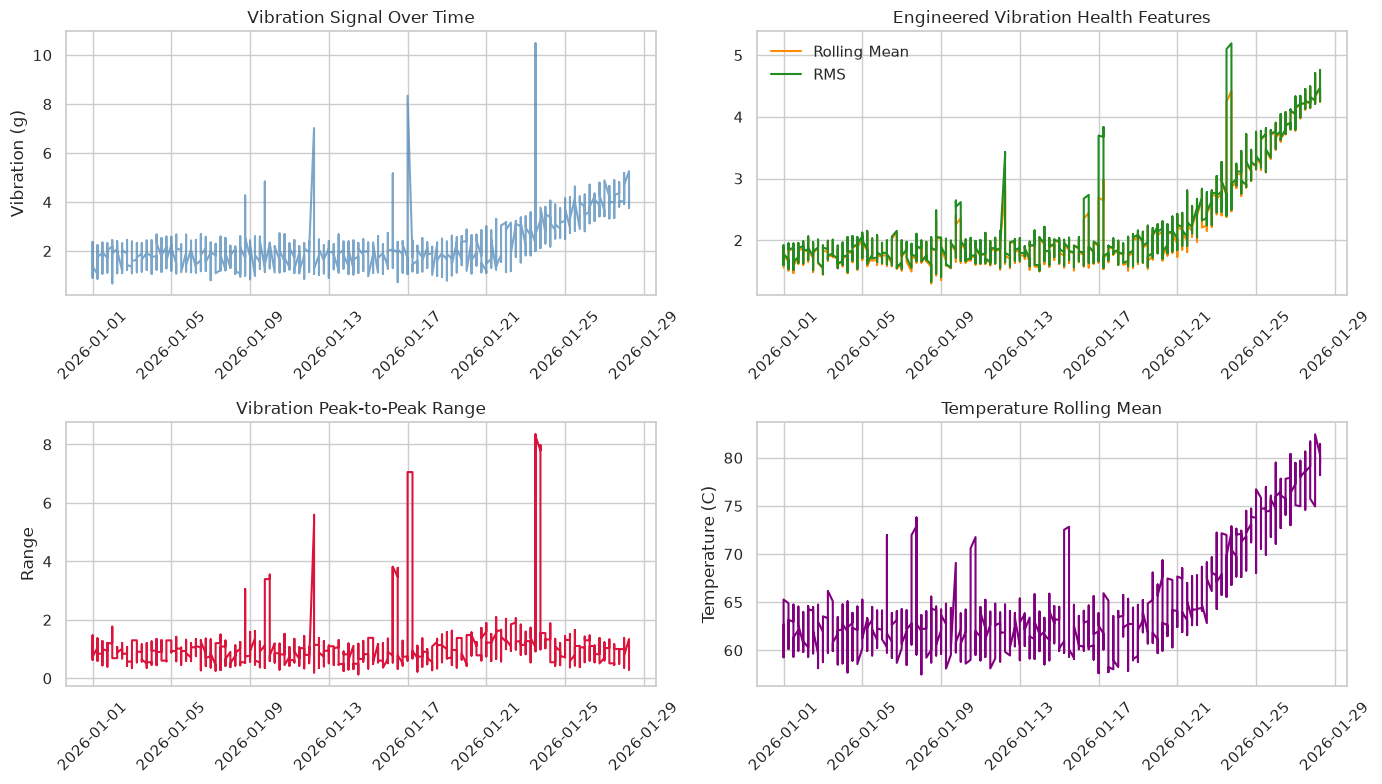

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(feature_df['timestamp'], feature_df['vibration_g'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Vibration Signal Over Time')
axes[0, 0].set_ylabel('Vibration (g)')

axes[0, 1].plot(feature_df['timestamp'], feature_df['vibration_roll_mean_6'], color='darkorange', label='Rolling Mean')
axes[0, 1].plot(feature_df['timestamp'], feature_df['vibration_rms_6'], color='forestgreen', label='RMS')
axes[0, 1].set_title('Engineered Vibration Health Features')
axes[0, 1].legend()

axes[1, 0].plot(feature_df['timestamp'], feature_df['vibration_peak_to_peak_6'], color='crimson')
axes[1, 0].set_title('Vibration Peak-to-Peak Range')
axes[1, 0].set_ylabel('Range')

axes[1, 1].plot(feature_df['timestamp'], feature_df['temp_roll_mean_6'], color='purple')
axes[1, 1].set_title('Temperature Rolling Mean')
axes[1, 1].set_ylabel('Temperature (C)')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 8. Create a PdM Target Variable

We will create a binary target where Healthy is 0 and Failing-like states are 1.


In [14]:
feature_df['target'] = feature_df['health_status'].map({'Healthy': 0, 'Warning': 1, 'Critical': 1})

feature_df[['health_status', 'target']].head(10)


,health_status,target
0,Healthy,0
1,Healthy,0
2,Healthy,0
3,Healthy,0
4,Healthy,0
5,Healthy,0
6,Healthy,0
7,Healthy,0
8,Healthy,0
9,Healthy,0


In [15]:
model_features = ['vibration_g', 'temperature_c', 'pressure_psi', 'vibration_roll_mean_6', 'vibration_rms_6', 'vibration_peak_to_peak_6', 'temp_roll_mean_6']
X = feature_df[model_features]
y = feature_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
print('Accuracy:', round(accuracy, 3))
print('Confusion Matrix:\n', cm)
print('\nClassification Report:\n')
print(classification_report(y_test, predictions, target_names=['Healthy', 'Failing']))


Accuracy: 0.944
Confusion Matrix:
 [[610  11]
 [ 33 134]]

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.95      0.98      0.97       621
     Failing       0.92      0.80      0.86       167

    accuracy                           0.94       788
   macro avg       0.94      0.89      0.91       788
weighted avg       0.94      0.94      0.94       788



## 9. Document the Business Implications

The predictive model can be used as an early warning system. Even a modest accuracy level helps maintenance teams prioritize inspections and reduce unplanned downtime.


In [16]:
print('Business implication:')
print('If the model can flag likely failing conditions early, maintenance teams can schedule inspection or replacement before a breakdown occurs.')
print('This reduces downtime, extends asset life, and improves operational reliability.')


Business implication:
If the model can flag likely failing conditions early, maintenance teams can schedule inspection or replacement before a breakdown occurs.
This reduces downtime, extends asset life, and improves operational reliability.
